In [1]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from src.training import (
    train, loss_fn, loss_fn_fa, loss_fn_ea, loss_fn_da, DEFAULT_CONFIG,
)
from src.teacher import make_wi_particles, make_arbitrary_particles
from src.metrics import rmd_to_projected
from src.utils import plot_rmd_curves, plot_particles_3d
import src.spaces as spaces

import plotly.io as pio
import matplotlib.pyplot as plt

spaces.SETUP = spaces.make_setup_matrix()
N_VALUES = [5, 10, 50, 100, 500]
N_REPS = 6
CONFIG = {**DEFAULT_CONFIG, "T": 4.0, "gr": 5}


In [2]:
teacher_wi = make_wi_particles()

results_wi = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for N in N_VALUES:
    for name in results_wi:
        results_wi[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        # Vanilla
        h = train(teacher_wi, N, jax.random.fold_in(key, 0), CONFIG, "si")
        results_wi["vanilla"][-1].append(rmd_to_projected(h["particles"][-1]))

        # DA
        h = train(teacher_wi, N, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da)
        results_wi["DA"][-1].append(rmd_to_projected(h["particles"][-1]))

        # FA
        h = train(teacher_wi, N, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa)
        results_wi["FA"][-1].append(rmd_to_projected(h["particles"][-1]))

        # EA
        h = train(teacher_wi, N, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea)
        results_wi["EA"][-1].append(rmd_to_projected(h["particles"][-1]))

    print(f"N={N} done")

W0426 16:20:27.487553 1245864 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


N=5 done
N=10 done
N=50 done
N=100 done
N=500 done


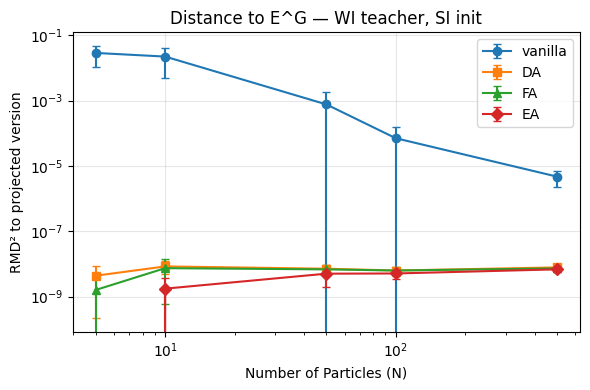

In [3]:
plot_rmd_curves(N_VALUES, results_wi, "Number of Particles (N)", "Distance to E^G — WI teacher, SI init", save_pdf=True)


In [4]:
teacher_arb = make_arbitrary_particles()

results_arb = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for N in N_VALUES:
    for name in results_arb:
        results_arb[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train(teacher_arb, N, jax.random.fold_in(key, 0), CONFIG, "si")
        results_arb["vanilla"][-1].append(rmd_to_projected(h["particles"][-1]))

        h = train(teacher_arb, N, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da)
        results_arb["DA"][-1].append(rmd_to_projected(h["particles"][-1]))

        h = train(teacher_arb, N, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa)
        results_arb["FA"][-1].append(rmd_to_projected(h["particles"][-1]))

        h = train(teacher_arb, N, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea)
        results_arb["EA"][-1].append(rmd_to_projected(h["particles"][-1]))

    print(f"N={N} done")

N=5 done
N=10 done
N=50 done
N=100 done
N=500 done


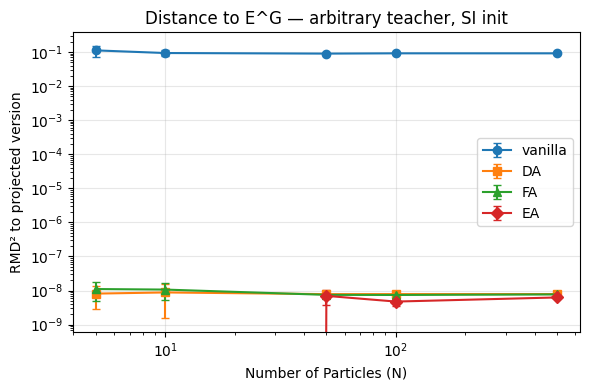

In [5]:
plot_rmd_curves(N_VALUES, results_arb, "Number of Particles (N)", "Distance to E^G — arbitrary teacher, SI init", save_pdf=True)


In [2]:
teacher = make_wi_particles()
N = 500
key = jax.random.PRNGKey(42)

configs = {"alpha": 50.0, "tau": 1e-4, "beta": 1e-6, "batch_size": 20, "T": 20.0, "gr": 5}

h_vanilla = train(teacher, N, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
# h_da = train(teacher, N, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da)
# print("DA done")
# h_fa = train(teacher, N, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa)
# print("FA done")
# h_ea = train(teacher, N, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea)
# print("EA done")

W0426 17:40:10.138319 1317239 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


vanilla done


In [10]:
fig = plot_particles_3d(h_vanilla["particles"][-1], teacher, "Student Particles (vanilla, matrix) - WI Teacher", show_invariant_plane=True)

In [11]:
fig.write_html('matrix_vanilla_WI.html')

In [26]:
plot_particles_3d(h_da["particles"][-1], teacher, "Student Particles (DA)", show_invariant_plane=True)

In [27]:
plot_particles_3d(h_fa["particles"][-1], teacher, "Student Particles (FA)", show_invariant_plane=True)

In [28]:
plot_particles_3d(h_ea["particles"][-1], teacher, "Student Particles (EA)", show_invariant_plane=True)

In [5]:
from src.teacher import make_arbitrary_particles

teacher_arb = make_arbitrary_particles()

h_vanilla_arb = train(teacher_arb, N, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
# h_da_arb = train(teacher_arb, N, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da)
# print("DA done")
# h_fa_arb = train(teacher_arb, N, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa)
# print("FA done")
# h_ea_arb = train(teacher_arb, N, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea)
# print("EA done")

vanilla done


In [7]:
fig = plot_particles_3d(h_vanilla_arb["particles"][-1], teacher_arb, "Arbitrary teacher — vanilla (matrix)", show_invariant_plane=True)

In [8]:
fig.write_image("matrix_vanilla_arb.pdf", scale=3)

In [9]:
fig.write_html('matrix_vanilla_arb.html')

In [31]:
plot_particles_3d(h_da_arb["particles"][-1], teacher_arb, "Arbitrary teacher — DA", show_invariant_plane=True)

In [32]:
plot_particles_3d(h_fa_arb["particles"][-1], teacher_arb, "Arbitrary teacher — FA", show_invariant_plane=True)

In [33]:
plot_particles_3d(h_ea_arb["particles"][-1], teacher_arb, "Arbitrary teacher — EA", show_invariant_plane=True)